# Exact and MPS lattice workflows with penq in PennyLane


`penq-pennylane` is a PennyLane plugin package with two public devices: an exact backend (`penq.qml_starter`) and an MPS backend (`penq.mps_starter`). The goal is deterministic, user-facing lattice workflows with a simple device switch.

This notebook shows a compact Community Demo story: plugin smoke test, a small exact-vs-MPS comparison, and one small lattice TFIM workflow.

All examples are intentionally small and reproducible so reviewers can run them quickly from top to bottom.


In [1]:
# User-facing installation (run in terminal, not inside notebook kernel):
# pip install penq-pennylane
# Optional plotting extras:
# pip install "penq-pennylane[plots]"


In [2]:
import numpy as np
import pennylane as qml

from QML.PenQ import compare_tfim_vqe_exact_vs_mps
from QML.PenQ import square_tfim_observables
from QML.PenQ import compare_square_tfim_exact_vs_mps
from QML.PenQ import compare_cubic_tfim_exact_vs_mps

SEED = 7
np.random.seed(SEED)

print("PennyLane version:", qml.__version__)
print("Seed:", SEED)


PennyLane version: 0.44.1
Seed: 7


## Minimal plugin smoke test
Create both public devices and run a tiny Bell-style QNode on each backend.


In [3]:
exact_dev = qml.device("penq.qml_starter", wires=2)
mps_dev = qml.device("penq.mps_starter", wires=2, max_bond_dim=8, svd_cutoff=1e-12)

@qml.qnode(exact_dev)
def bell_exact(theta):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

@qml.qnode(mps_dev)
def bell_mps(theta):
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

theta = 0.2
smoke_result = {
    "theta": theta,
    "exact_zz": float(bell_exact(theta)),
    "mps_zz": float(bell_mps(theta)),
}
smoke_result


{'theta': 0.2, 'exact_zz': 0.9800665778412415, 'mps_zz': 0.9800665778412415}

## Small exact-vs-MPS comparison
Use the built-in comparison workflow for a small 1D TFIM adaptive VQE case.


In [4]:
cmp = compare_tfim_vqe_exact_vs_mps(
    n=4,
    J=1.0,
    h=0.7,
    max_layers=2,
    max_bond_dim=8,
    svd_cutoff=1e-12,
    steps=1,
    grid_points=5,
    seed=SEED,
    tol=1e-6,
)

comparison_summary = {
    "exact_energy": float(cmp["exact"]["energy"]),
    "mps_energy": float(cmp["mps"]["energy"]),
    "abs_energy_error": float(cmp["abs_energy_error"]),
    "exact_layers_used": int(cmp["exact"]["layers_used"]),
    "mps_layers_used": int(cmp["mps"]["layers_used"]),
}
comparison_summary


{'exact_energy': -2.7999999999999976,
 'mps_energy': -2.799999999999998,
 'abs_energy_error': 4.440892098500626e-16,
 'exact_layers_used': 0,
 'mps_layers_used': 0}

## Small lattice workflow example (2x2 square TFIM)
Run one compact mapped-lattice observable workflow on exact and MPS backends.


In [5]:
sq_exact = square_tfim_observables(
    Lx=2,
    Ly=2,
    Jx=1.0,
    Jy=0.8,
    h=0.6,
    backend="qml",
    seed=SEED,
)

sq_mps = square_tfim_observables(
    Lx=2,
    Ly=2,
    Jx=1.0,
    Jy=0.8,
    h=0.6,
    backend="mps",
    max_bond_dim=8,
    svd_cutoff=1e-12,
    seed=SEED,
)

lattice_summary = {
    "exact_energy": float(sq_exact["energy"]),
    "mps_energy": float(sq_mps["energy"]),
    "abs_energy_error": float(abs(sq_mps["energy"] - sq_exact["energy"])),
    "exact_magnetization_x": float(sq_exact["magnetization_x"]),
    "mps_magnetization_x": float(sq_mps["magnetization_x"]),
}
lattice_summary


{'exact_energy': -2.8516915654591592,
 'mps_energy': -2.8516915654591535,
 'abs_energy_error': 5.773159728050814e-15,
 'exact_magnetization_x': 0.6461766964438524,
 'mps_magnetization_x': 0.646176696443851}

## 2D and 3D exact-vs-MPS snapshots
Use compact built-in comparison helpers for a square 2D case and a tiny cubic 3D case.

In [6]:
sq_cmp = compare_square_tfim_exact_vs_mps(
    Lx=2,
    Ly=2,
    Jx=1.0,
    Jy=0.8,
    h=0.6,
    max_bond_dim=8,
    svd_cutoff=1e-12,
    seed=SEED,
)

cubic_cmp = compare_cubic_tfim_exact_vs_mps(
    Lx=2,
    Ly=2,
    Lz=1,
    Jx=1.0,
    Jy=0.8,
    Jz=0.6,
    h=0.6,
    max_bond_dim=8,
    svd_cutoff=1e-12,
    seed=SEED,
)

lattice_compare_summary = {
    "2d_abs_energy_error": float(sq_cmp["abs_energy_error"]),
    "3d_abs_energy_error": float(cubic_cmp["abs_energy_error"]),
    "2d_exact_energy": float(sq_cmp["exact_energy"]),
    "2d_mps_energy": float(sq_cmp["mps_energy"]),
    "3d_exact_energy": float(cubic_cmp["exact_energy"]),
    "3d_mps_energy": float(cubic_cmp["mps_energy"]),
}
lattice_compare_summary

{'2d_abs_energy_error': 5.773159728050814e-15,
 '3d_abs_energy_error': 4.440892098500626e-15,
 '2d_exact_energy': -2.8516915654591592,
 '2d_mps_energy': -2.8516915654591535,
 '3d_exact_energy': -2.8465666868934534,
 '3d_mps_energy': -2.846566686893449}

## Small plot (1D vs 2D vs 3D)
Plot absolute exact-vs-MPS energy error for the three compact examples in this notebook.

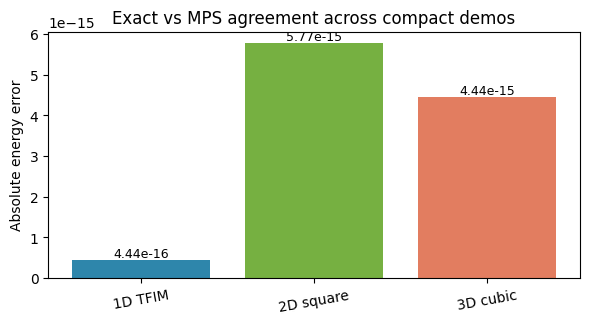

In [7]:
try:
    import matplotlib.pyplot as plt

    labels = ["1D TFIM", "2D square", "3D cubic"]
    errors = [
        float(comparison_summary["abs_energy_error"]),
        float(lattice_compare_summary["2d_abs_energy_error"]),
        float(lattice_compare_summary["3d_abs_energy_error"]),
    ]

    fig, ax = plt.subplots(figsize=(6, 3.5))
    bars = ax.bar(labels, errors, color=["#2E86AB", "#76B041", "#E27D60"])
    ax.set_ylabel("Absolute energy error")
    ax.set_title("Exact vs MPS agreement across compact demos")
    ax.tick_params(axis="x", rotation=10)

    for bar, val in zip(bars, errors):
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height(),
            f"{val:.2e}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Plot skipped (matplotlib unavailable or plotting backend issue):", exc)

## Reproducibility and environment


In [8]:
import importlib.metadata as im

print("seed =", SEED)
print("penq-pennylane version =", im.version("penq-pennylane"))
qml.about()


seed = 7
penq-pennylane version = 1.2.0
Name: pennylane
Version: 0.44.1
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /data/mahasiswa/adi/penq-pennylane/.venv/lib/python3.13/site-packages
Platform info:           Linux-6.12.74+deb13+1-amd64-x86_64-with-glibc2.41
Python version:          3.13.5
Numpy version:           2.4.4
Scipy version:           1.17.1
JAX version:             None
Installed devices:
- default.clifford (pennylane-0.44.1)
- default.gaussian (pennylane-0.44.1)
- default.mixed (pennylane-0.44.1)
- default.qubit (pennylane-0.44.1)
- default.qutrit (pennylane-0.44.1)
- default.qutrit.mixed (pennylane-0.44.1)
- default.tensor (pennylane-0.44.1)
- null.qubit (pennylane-0.44.1)
- reference.qubit (pennylane-0.44.1)
- penq.mps_starter (penq-pennylane-1.2.0)
- penq.qml_starter (penq-pennylane-1.2.0)


`penq-pennylane` currently targets a compact and deterministic scope: exact and MPS backends, reproducible lattice workflows, and lightweight exact-vs-MPS comparisons that are easy to integrate into PennyLane user pipelines.
